In [3]:
import os
import json

def read_json_file(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

def add_not_to_exc(exc_data):
    return {
        "NOT": {
            "left": exc_data
        }
    }

def combine_criteria(inc_data, exc_data):
    return {
        "AND": {
            "left": inc_data,
            "right": exc_data
        }
    }

def process_files(input_directory, output_directory):
    for filename in os.listdir(input_directory):
        nct_number = filename.split('_')[0]
        inc_file = os.path.join(input_directory, f"{nct_number}_inc.json")
        exc_file = os.path.join(input_directory, f"{nct_number}_exc.json")

        if os.path.exists(inc_file) and os.path.exists(exc_file):
            inc_data = read_json_file(inc_file)
            exc_data = read_json_file(exc_file)
            # NOT Knoten für Ausschlusskriterien
            exc_data_with_not = add_not_to_exc(exc_data)
            # Kriterien kombinieren
            combined_data = combine_criteria(inc_data, exc_data_with_not)
            output_file = os.path.join(output_directory, f"{nct_number}.json")
            
            with open(output_file, 'w') as file:
                json.dump(combined_data, file, indent=2)

            print(f"Combined file created: {output_file}")

In [4]:
input_directory = "lct_p2"
output_directory = "lct_p2_final"
process_files(input_directory, output_directory)

Combined file created: lct_p2_final\NCT03860012.json
Combined file created: lct_p2_final\NCT03860012.json
Combined file created: lct_p2_final\NCT03860025.json
Combined file created: lct_p2_final\NCT03860025.json
Combined file created: lct_p2_final\NCT03860038.json
Combined file created: lct_p2_final\NCT03860038.json
Combined file created: lct_p2_final\NCT03860064.json
Combined file created: lct_p2_final\NCT03860064.json
Combined file created: lct_p2_final\NCT03860090.json
Combined file created: lct_p2_final\NCT03860090.json
Combined file created: lct_p2_final\NCT03860103.json
Combined file created: lct_p2_final\NCT03860103.json
Combined file created: lct_p2_final\NCT03860116.json
Combined file created: lct_p2_final\NCT03860116.json
Combined file created: lct_p2_final\NCT03860142.json
Combined file created: lct_p2_final\NCT03860142.json
Combined file created: lct_p2_final\NCT03860168.json
Combined file created: lct_p2_final\NCT03860168.json
Combined file created: lct_p2_final\NCT0386018

Logic tree visualized and saved: lct_p2_final_pics\NCT03860012_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860025_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860038_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860064_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860090_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860103_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860116_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860142_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860168_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860181_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860194_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860220_logic_tree.png
Logic tree visualized and saved: lct_p2_final_pics\NCT03860233_l

KeyboardInterrupt: 

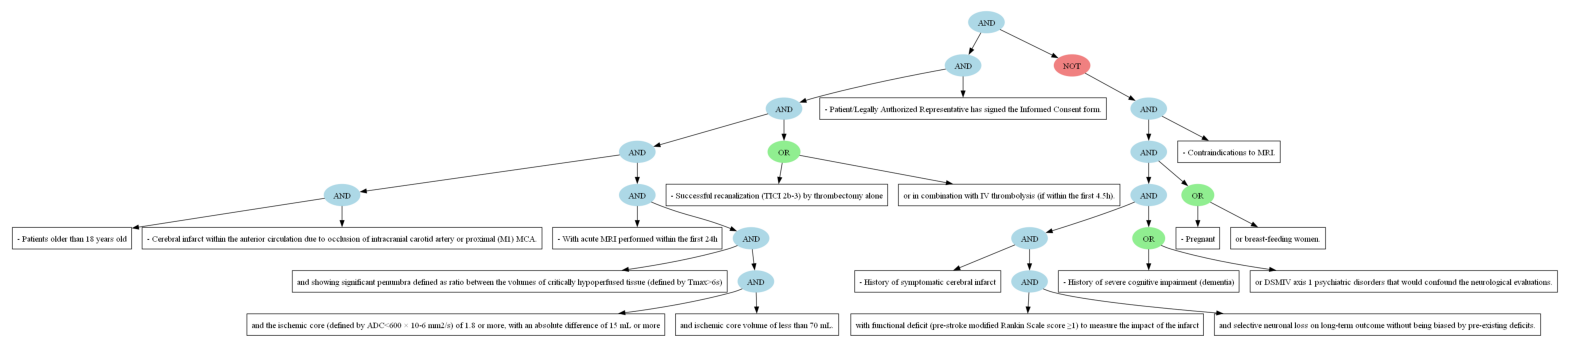

In [8]:
import os
import json
from graphviz import Digraph
from PIL import Image
import matplotlib.pyplot as plt

def read_json_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)

def parse_logic_to_tree(logic, graph, parent=None, node_id=0):
    if 'raw_text' in logic:
        node_label = logic['raw_text']
        graph.node(str(node_id), label=node_label, shape='box')
        if parent is not None:
            graph.edge(parent, str(node_id))
        return node_id

    for key in logic:
        if key in ('AND', 'OR', 'NOT'):
            operator = key
            node_label = operator
            current_node_id = node_id
            color = 'lightblue' if operator == 'AND' else 'lightgreen' if operator == 'OR' else 'lightcoral'
            graph.node(str(current_node_id), label=node_label, color=color, fontcolor='black', style='filled', fillcolor=color)
            if parent is not None:
                graph.edge(parent, str(current_node_id))

            operands = logic[key]
            node_id += 1
            if 'left' in operands:
                left_id = parse_logic_to_tree(operands['left'], graph, str(current_node_id), node_id)
                node_id = left_id + 1
            if 'right' in operands:
                right_id = parse_logic_to_tree(operands['right'], graph, str(current_node_id), node_id)
                node_id = right_id + 1
            if operator == 'NOT':
                node_id += 1
    return node_id

def visualize_logic_tree(logic):
    graph = Digraph(format='png', encoding='utf-8')
    parse_logic_to_tree(logic, graph)
    return graph

def plot_and_save_graph(logic, graph_title, output_filename):
    graph = visualize_logic_tree(logic)
    graph.render(filename='temp', view=False, cleanup=True)
    image = Image.open('temp.png')
    plt.figure(figsize=(20, 15))
    plt.imshow(image)
    plt.axis('off')
    plt.title(graph_title)
    plt.savefig(output_filename)
    plt.close()

def process_and_visualize_files(input_directory, output_directory):
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    for filename in os.listdir(input_directory):
        if filename.endswith('.json'):
            file_path = os.path.join(input_directory, filename)
            nct_number = filename.split('.')[0]

            logic_data = read_json_file(file_path)

            graph_title = f""
            output_filename = os.path.join(output_directory, f"{nct_number}_logic_tree.png")

            plot_and_save_graph(logic_data, graph_title, output_filename)

            print(f"Logic tree visualized and saved: {output_filename}")

# Nutzung des Skripts
input_directory = "lct_p2_final"
output_directory = "lct_p2_final_pics"
process_and_visualize_files(input_directory, output_directory)

In [12]:
import os
import json
import re
import textwrap

def read_json_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)

def add_line_breaks(formula, max_length=80):
    lines = textwrap.wrap(formula, max_length, break_long_words=False, break_on_hyphens=False)
    return r' \\ &'.join(lines)

def clean_text(text):
    # Entfernt Zeilennummern, führende/nachfolgende Leerzeichen und Bindestriche am Anfang
    text = re.sub(r'^\d+\.\s*', '', text)
    text = text.strip()
    text = re.sub(r'^-\s*', '', text)
    return text

def json_to_logic_formula(data, is_root=True, depth=0):
    if 'raw_text' in data:
        text = clean_text(data['raw_text'])
        return r'\text{' + text + '}'

    for key in data:
        if key in ('AND', 'OR', 'NOT'):
            try:
                left = json_to_logic_formula(data[key]['left'], False, depth + 1)
                if key == 'NOT':
                    formula = r'\neg (' + left + ')'
                else:
                    right = json_to_logic_formula(data[key]['right'], False, depth + 1)
                    if key == 'AND':
                        formula = r'({left} \wedge {right})'.format(left=left, right=right)
                    else:  # OR
                        formula = r'({left} \vee {right})'.format(left=left, right=right)

                if is_root:
                    return add_line_breaks(formula)
                else:
                    return formula
            except KeyError:
                print(f"KeyError in data structure. Skipping this part.")
                return ""

    return ""  # Return empty string if no valid structure found

def create_latex_document(nct_number, formula):
    latex_template = r'''
\begin{{center}}
\Large\textbf{{Aussagenlogische Formel für NCT{nct_number}}}
\end{{center}}

\vspace{{1cm}}

\begin{{equation}}
\begin{{split}}
{formula}
\end{{split}}
\end{{equation}}

'''
    return latex_template.format(nct_number=nct_number, formula=formula)

def process_json_files(input_directory, output_directory):
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    for filename in os.listdir(input_directory):
        if filename.endswith('.json'):
            file_path = os.path.join(input_directory, filename)
            nct_number = filename.split('.')[0]

            try:
                logic_data = read_json_file(file_path)
                formula = json_to_logic_formula(logic_data)

                if formula:  # Only create LaTeX file if formula is not empty
                    latex_content = create_latex_document(nct_number, formula)

                    output_filename = os.path.join(output_directory, f"{nct_number}_logic_formula.tex")
                    with open(output_filename, 'w', encoding='utf-8') as file:
                        file.write(latex_content)

                    print(f"LaTeX file created: {output_filename}")
                else:
                    print(f"Skipping {filename} due to invalid structure")
            except Exception as e:
                print(f"Error processing {filename}: {str(e)}")

input_directory = "lct_p2_final"
output_directory = "lct_p2_final_latex"
process_json_files(input_directory, output_directory)

LaTeX file created: lct_p2_final_latex\NCT03860012_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860025_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860038_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860064_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860090_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860103_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860116_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860142_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860168_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860181_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860194_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860220_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860233_logic_formula.tex
LaTeX file created: lct_p2_final_latex\NCT03860246_logic_formula.tex
LaTeX file created: lct_p2_final_l